# Target stars: $gmag3$ distribution

等時線解析の posterior から各星の `gmag3` の中央値を求め、1 星につき 1 点として実視等級分布を表示する。

In [1]:
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from rot_evol import (
    ANALYSIS_ROOT,
    ISO_LABEL,
    SPEC_LABEL,
    find_frame_dir,
    frame_ids_from_observation_log,
    result_path,
    posterior_mean_std,
)

OBSERVATION_LOG = Path("observation_log.csv")
LOG_QUERY = ""

# Trash を除き、同じ天体に複数観測がある場合は Count (e-) 最大の観測を使う。
frame_ids = frame_ids_from_observation_log(
    OBSERVATION_LOG,
    query=LOG_QUERY,
    exclude_tags=("Trash",),
    keep_highest_sn_per_object=True,
    sn_column="Count (e-)",
)
print(f"{len(frame_ids)} target stars")


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


216 target stars


In [2]:
rows = []
for frame_id in tqdm(frame_ids, desc="Loading isochrone posterior", unit="star"):
    nc_path = result_path(find_frame_dir(ANALYSIS_ROOT, frame_id), ISO_LABEL)
    posterior = az.from_netcdf(nc_path).posterior
    if "gmag3" not in posterior:
        raise KeyError(f"'gmag3' is absent from {nc_path}")

    gmag3 = np.asarray(posterior["gmag3"], dtype=float).reshape(-1)
    gmag3 = gmag3[np.isfinite(gmag3)]
    if gmag3.size == 0:
        raise ValueError(f"No finite gmag3 samples in {nc_path}")

    rows.append({"frame_id": frame_id, "gmag3_median": np.median(gmag3)})

targets = pd.DataFrame(rows)
targets


Loading isochrone posterior:   0%|          | 0/216 [00:00<?, ?star/s]

,frame_id,gmag3_median
0,00029409,6.137944
1,00029410,6.090782
2,00029412,6.173176
3,00029413,6.667793
4,00029414,6.034835
...,...,...
211,00031183,6.285419
212,00031184,6.528173
213,00031185,6.842428
214,00031186,6.615879


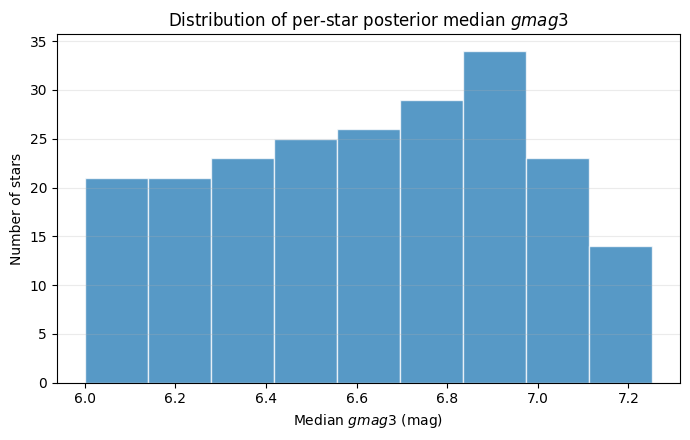

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(
    targets["gmag3_median"],
    bins="auto",
    color="C0",
    alpha=0.75,
    edgecolor="white",
)
ax.set(
    xlabel=r"Median $gmag3$ (mag)",
    ylabel="Number of stars",
    title=r"Distribution of per-star posterior median $gmag3$",
)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()


## Gaia color–magnitude diagram

`gaia_candidates.csv` の採用天体について、視差 $\varpi$ を mas として $M_G = G + 5\log_{10}(\varpi) - 10$ から絶対 G 等級を計算する。ここでは消光補正を行わない。
点の色は specfit posterior mean の $[\mathrm{Fe}/\mathrm{H}]$ を表す。GSP-Phot $T_{\rm eff}$ と $G_{BP}-G_{RP}$ の3次多項式関係を当てはめ、その関係から上側の有効温度軸を構成する。

In [4]:
gaia_rows = []
for frame_id in tqdm(frame_ids, desc="Loading Gaia metadata", unit="star"):
    frame_dir = find_frame_dir(ANALYSIS_ROOT, frame_id)
    iso_dir = frame_dir / ISO_LABEL
    summary = pd.read_csv(
        iso_dir / "summary.csv",
        dtype={"gaia_source_id": "string"},
    )
    metadata = pd.read_csv(
        iso_dir / "gaia_candidates.csv",
        dtype={"source_id": "string"},
    )

    source_id = summary.loc[0, "gaia_source_id"]
    selected = metadata.loc[metadata["source_id"] == source_id]
    if len(selected) != 1:
        raise ValueError(
            f"Expected one Gaia metadata row for frame_id={frame_id}, "
            f"source_id={source_id}; found {len(selected)}"
        )

    spec_nc_path = result_path(frame_dir, SPEC_LABEL)
    specfit_feh, specfit_feh_err = posterior_mean_std(
        spec_nc_path, "feh"
    )
    row = selected.iloc[0]
    gaia_rows.append(
        {
            "frame_id": frame_id,
            "source_id": source_id,
            "phot_g_mean_mag": row["phot_g_mean_mag"],
            "parallax": row["parallax"],  # mas
            "bp_rp": row["bp_rp"],
            "gaia_gspphot_teff": row["teff_gspphot"],
            "specfit_feh": specfit_feh,
            "specfit_feh_err": specfit_feh_err,
        }
    )

gaia_targets = pd.DataFrame(gaia_rows)
hr_columns = ["phot_g_mean_mag", "parallax", "bp_rp"]
numeric_columns = hr_columns + ["gaia_gspphot_teff", "specfit_feh", "specfit_feh_err"]
gaia_targets[numeric_columns] = gaia_targets[numeric_columns].apply(pd.to_numeric, errors="coerce")
valid = np.isfinite(gaia_targets[hr_columns]).all(axis=1) & (gaia_targets["parallax"] > 0)
if not valid.all():
    print(f"Excluded {(~valid).sum()} stars with invalid Gaia metadata")
gaia_targets = gaia_targets.loc[valid].copy()
gaia_targets["absolute_g_mag"] = (
    gaia_targets["phot_g_mean_mag"]
    + 5 * np.log10(gaia_targets["parallax"])
    - 10
)
gaia_targets


Loading Gaia metadata:   0%|          | 0/216 [00:00<?, ?star/s]

,frame_id,source_id,phot_g_mean_mag,parallax,bp_rp,gaia_gspphot_teff,specfit_feh,specfit_feh_err,absolute_g_mag
0,00029409,705631623149811712,6.137405,18.083395,0.624197,6304.0435,-0.136337,0.012229,2.423805
1,00029410,716109930305855360,6.090416,36.520069,0.677261,6130.9770,0.063267,0.014361,3.903074
2,00029412,918107434852949888,6.172532,45.582614,0.788322,5740.3300,-0.005300,0.020788,4.466528
3,00029413,1016229845380801408,6.667306,18.739170,0.552864,6565.9630,0.145559,0.037497,3.031057
4,00029414,1019361632454363904,6.033801,34.251789,0.601628,6400.1514,-0.453993,0.012694,3.707217
...,...,...,...,...,...,...,...,...,...
211,00031183,1814241194252808704,6.285079,47.745688,0.786007,5746.5730,-0.116768,0.018780,4.679749
212,00031184,1760316677257596288,6.526107,21.339133,0.640620,6225.5370,-0.330944,0.016132,3.171991
213,00031185,1789231256087445120,6.843096,22.820629,0.641146,6234.2960,-0.010028,0.010910,3.634734
214,00031186,1785414129672353408,6.615803,19.168227,0.509069,6780.0110,-0.000627,0.039775,3.028713


Teff(BP-RP) cubic coefficients [x^3, x^2, x, 1]:
[-2924.16435418  7673.33697997 -9890.86344551 10198.43776375]
Fit sample: 212 stars; RMS = 29.9 K


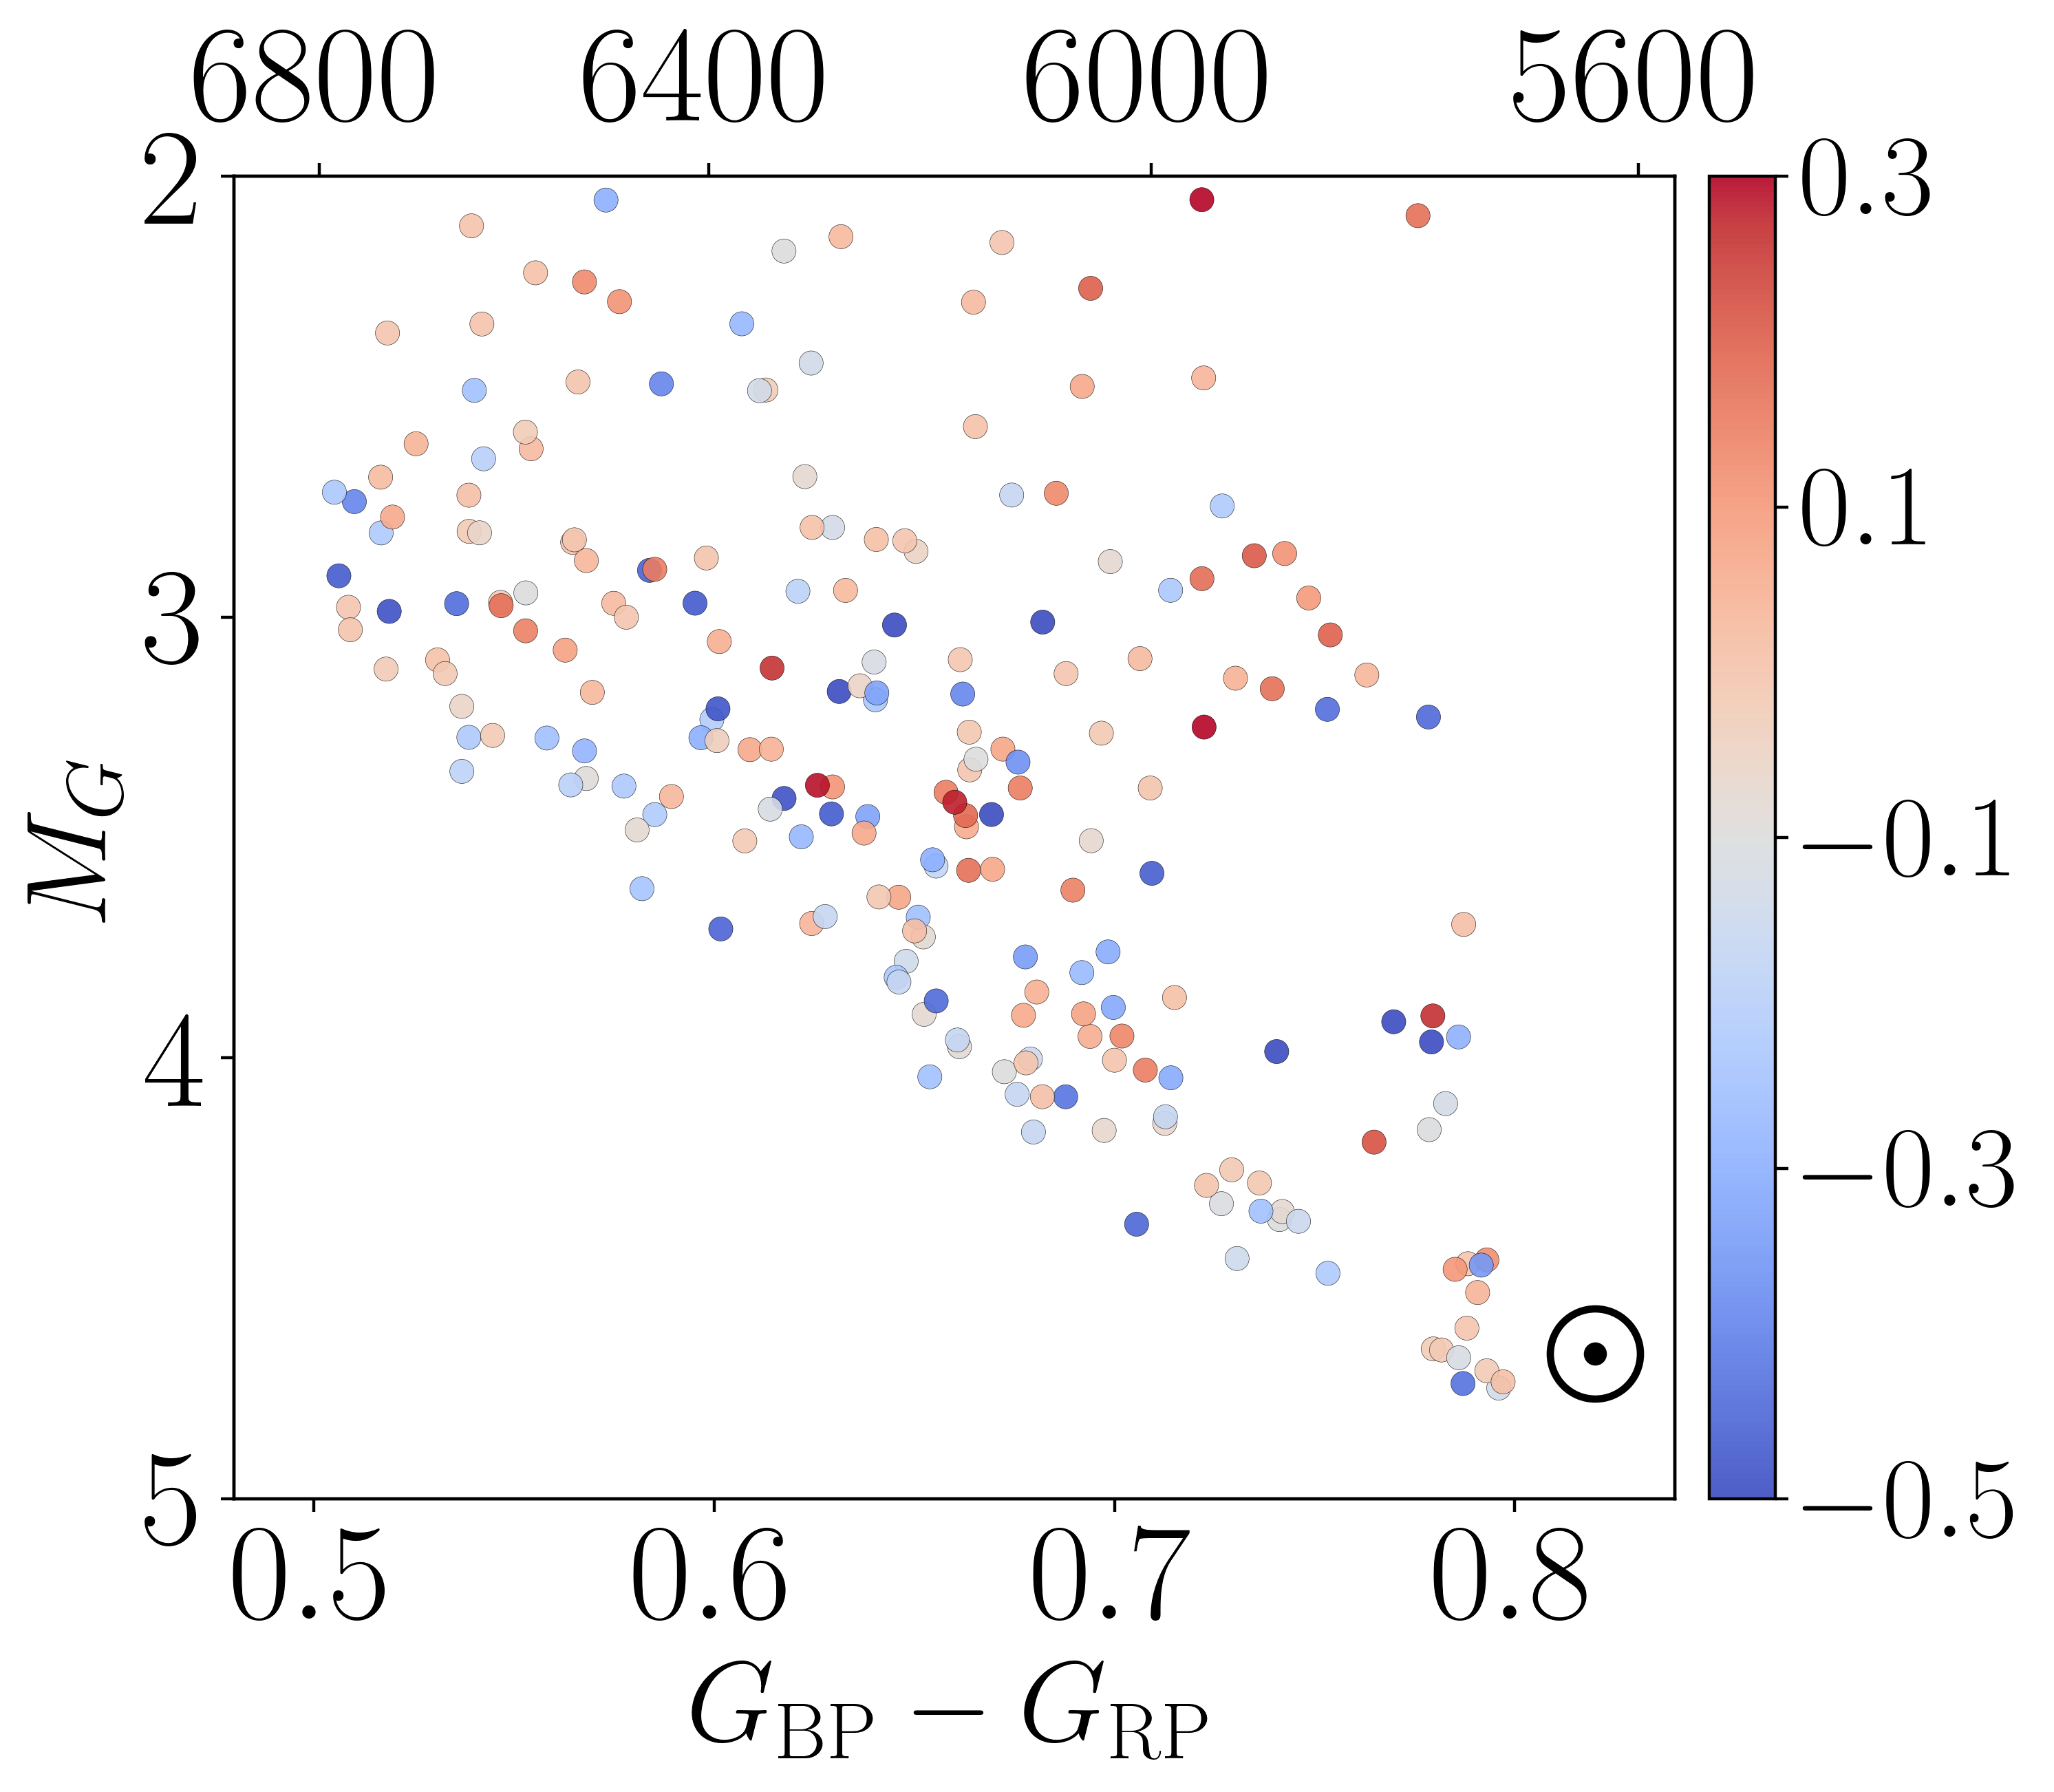

In [15]:
plt.rcParams.update(
    {
    "font.size": 23,
    "axes.labelsize": 30,
    "xtick.labelsize": 36,
    "ytick.labelsize": 36,
    "figure.dpi": 400,
    "text.usetex": True,
    "font.family": "serif",
}
)
fit_columns = ["bp_rp", "gaia_gspphot_teff"]
fit_valid = np.isfinite(gaia_targets[fit_columns]).all(axis=1)
if fit_valid.sum() < 4:
    raise ValueError("At least four finite BP-RP/Teff pairs are required")

bp_rp_fit = gaia_targets.loc[fit_valid, "bp_rp"].to_numpy()
teff_fit = gaia_targets.loc[fit_valid, "gaia_gspphot_teff"].to_numpy()
teff_poly_coefficients = np.polyfit(bp_rp_fit, teff_fit, deg=3)
teff_from_bprp = np.poly1d(teff_poly_coefficients)
teff_residuals = teff_fit - teff_from_bprp(bp_rp_fit)
teff_rms = np.sqrt(np.mean(teff_residuals**2))
print("Teff(BP-RP) cubic coefficients [x^3, x^2, x, 1]:")
print(teff_poly_coefficients)
print(f"Fit sample: {fit_valid.sum()} stars; RMS = {teff_rms:.1f} K")

metallicity_valid = np.isfinite(gaia_targets["specfit_feh"])

fig, ax = plt.subplots(figsize=(8, 7))
if (~metallicity_valid).any():
    ax.scatter(
        gaia_targets.loc[~metallicity_valid, "bp_rp"],
        gaia_targets.loc[~metallicity_valid, "absolute_g_mag"],
        s=20, color="0.75", alpha=0.8, edgecolors="none",
        label="No specfit [Fe/H]",
    )

from matplotlib.colors import TwoSlopeNorm

feh = gaia_targets.loc[metallicity_valid, "specfit_feh"]
# norm = TwoSlopeNorm(
#     vmin=feh.min(),
#     vcenter=-0.1,
#     vmax=feh.max(),
# )
from matplotlib.colors import Normalize

norm = Normalize(vmin=-0.5, vmax=0.3, clip=True)

points = ax.scatter(
    gaia_targets.loc[metallicity_valid, "bp_rp"],
    gaia_targets.loc[metallicity_valid, "absolute_g_mag"],
    c=feh,
    # c="k",
    s=40,
    cmap="coolwarm",
    norm=norm,
    alpha=0.9,
    edgecolors="k",
    linewidths=0.1,
)

colorbar = fig.colorbar(points, ax=ax, pad=0.02)
colorbar.set_ticks([-0.5, -0.3, -0.1, 0.1, 0.3])
colorbar.ax.tick_params(labelsize=30)

SOLAR_BP_RP = 0.82
SOLAR_ABSOLUTE_G_MAG = 4.67
ax.scatter(
    SOLAR_BP_RP, SOLAR_ABSOLUTE_G_MAG,
    marker=r"$\odot$", c="k", s=600, zorder=5,
    label=r"Sun ($\odot$)",

)

# ax.legend(loc="best", fontsize=12, frameon=False)

# colorbar.set_label(r"specfit $[\mathrm{Fe}/\mathrm{H}]$")
ax.set(
    xlabel=r"$G_\mathrm{BP} - G_\mathrm{RP}$",
    ylabel=r"$M_G$",
    # title="Gaia color–magnitude diagram",
    ylim=(2,5),
    xlim=(0.48, 0.84)
)
ax.invert_yaxis()

ax.set_xticks([0.5, 0.6, 0.7, 0.8])

axis_bp_rp_grid = np.linspace(*ax.get_xlim(), 2000)
axis_teff_grid = teff_from_bprp(axis_bp_rp_grid)
if not np.all(np.diff(axis_teff_grid) < 0):
    raise ValueError("The fitted Teff relation must decrease across the HR-axis range")

teff_tick_step = 400.0
teff_tick_high = np.floor(axis_teff_grid.max() / teff_tick_step) * teff_tick_step
teff_tick_low = np.ceil(axis_teff_grid.min() / teff_tick_step) * teff_tick_step
teff_ticks = np.arange(
    teff_tick_high, teff_tick_low - 0.5 * teff_tick_step, -teff_tick_step
)
bp_rp_ticks = np.interp(
    teff_ticks, axis_teff_grid[::-1], axis_bp_rp_grid[::-1]
)
teff_axis = ax.twiny()
teff_axis.set_xlim(ax.get_xlim())
teff_axis.set_xticks(bp_rp_ticks)
teff_axis.set_xticklabels([f"{value:.0f}" for value in teff_ticks])
# teff_axis.set_xlabel(r"Gaia GSP-Phot $T_{\rm eff}$ [K]")

fig.tight_layout()
plt.show()


## $T_{\rm eff}$--$G_{BP}-G_{RP}$ relation check

上段で Gaia GSP-Phot 有効温度と色のデータおよび3次多項式を比較し、下段で色に対する残差を確認する。点の色は specfit posterior mean の $[\mathrm{Fe}/\mathrm{H}]$ を表す。

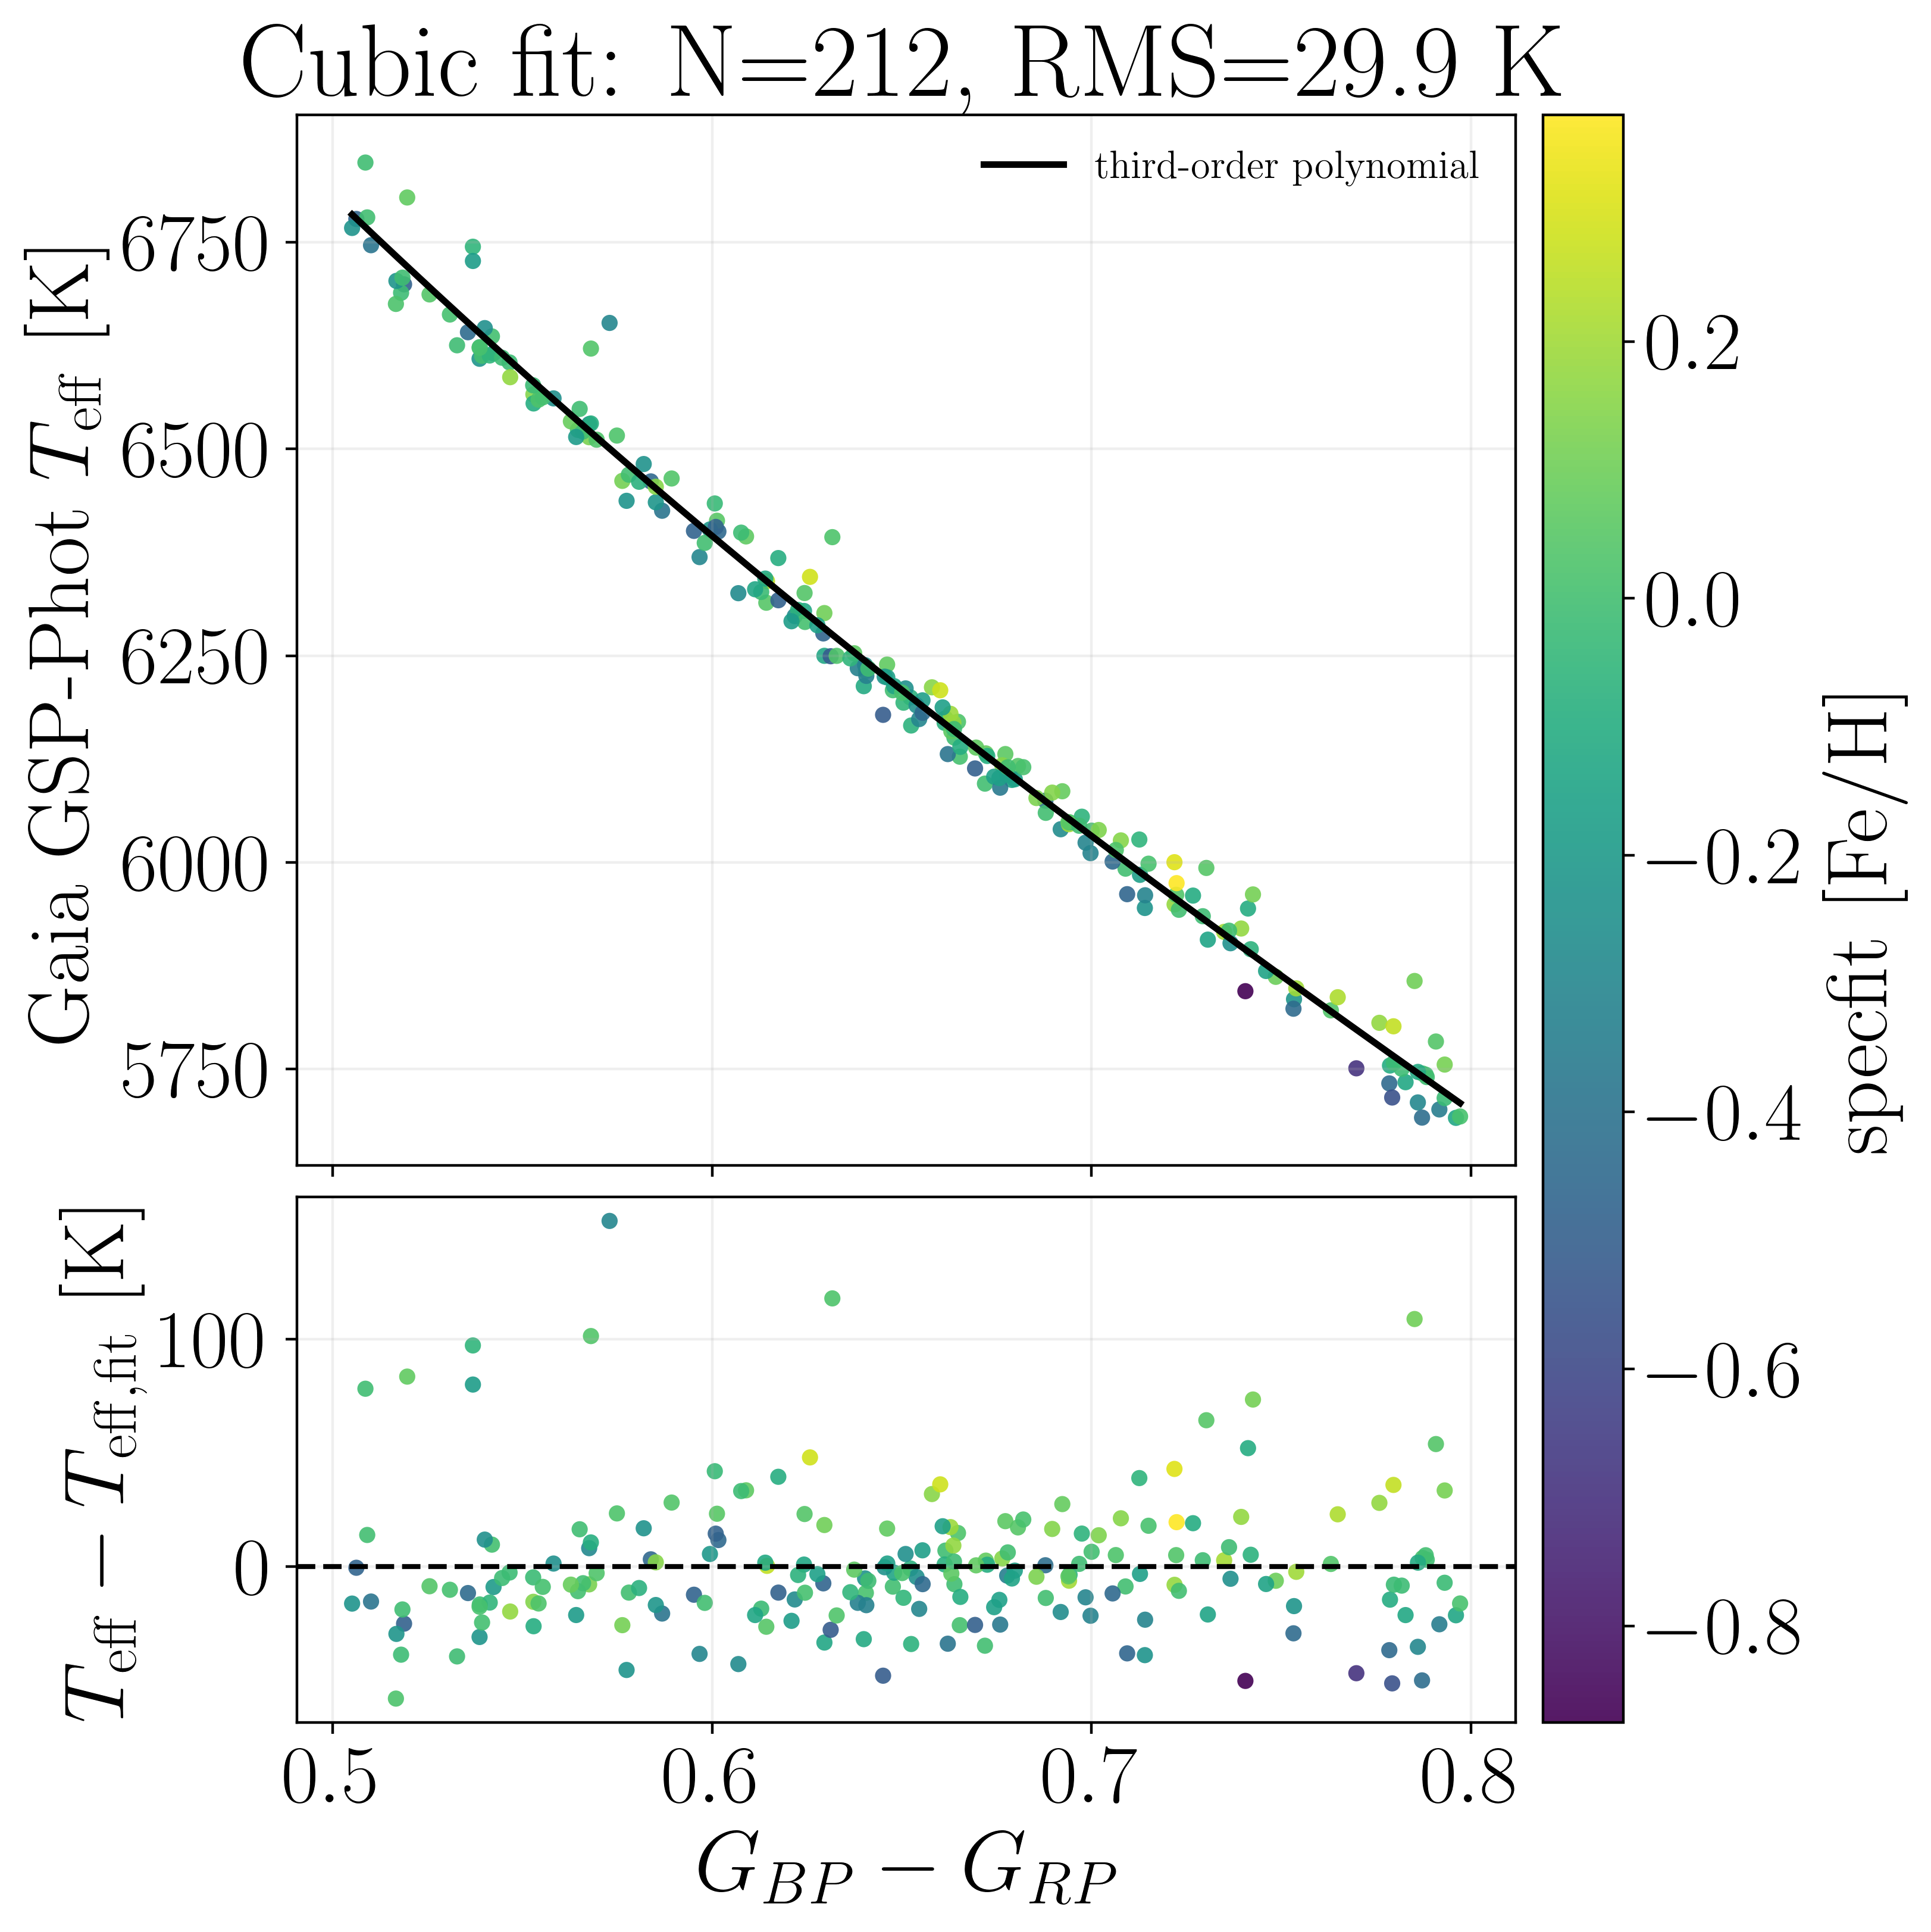

In [ ]:
diagnostic_feh = gaia_targets.loc[fit_valid, "specfit_feh"].to_numpy()
bp_rp_grid = np.linspace(bp_rp_fit.min(), bp_rp_fit.max(), 500)

fig_relation, (ax_relation, ax_residual) = plt.subplots(
    2, 1, figsize=(8, 8), sharex=True,
    gridspec_kw={"height_ratios": (2, 1)}, layout="constrained",
)
relation_points = ax_relation.scatter(
    bp_rp_fit, teff_fit,
    c=diagnostic_feh,
    cmap=points.cmap,
    norm=points.norm,
    s=24,
    alpha=0.9,
    edgecolors="none",
)
ax_relation.plot(
    bp_rp_grid, teff_from_bprp(bp_rp_grid),
    color="k", lw=2, label="third-order polynomial",
)
ax_relation.set(
    ylabel=r"Gaia GSP-Phot $T_{\rm eff}$ [K]",
    title=f"Cubic fit: N={fit_valid.sum()}, RMS={teff_rms:.1f} K",
)
ax_relation.legend(fontsize=12, frameon=False)
ax_relation.grid(alpha=0.2)

ax_residual.scatter(
    bp_rp_fit, teff_residuals,
    c=diagnostic_feh,
    cmap=points.cmap,
    norm=points.norm,
    s=24,
    alpha=0.9,
    edgecolors="none",
)
ax_residual.axhline(0.0, color="k", lw=1.5, ls="--")
ax_residual.set(
    xlabel=r"$G_{BP} - G_{RP}$",
    ylabel=r"$T_{\rm eff} - T_{\rm eff,fit}$ [K]",
)
ax_residual.grid(alpha=0.2)

relation_colorbar = fig_relation.colorbar(
    relation_points, ax=[ax_relation, ax_residual], pad=0.02
)
relation_colorbar.set_label(r"specfit $[\mathrm{Fe}/\mathrm{H}]$")
plt.show()


## Kepler light curve of a solar-rotation analogue

KIC 11599385 は太陽に近い基本特性を持つ太陽型星で、文献の自転周期は $P_{\rm rot}=23.94$ day である。MAST で公開されている Kepler Quarter 5 の長時間積分（約30分 cadence）PDCSAP 光度曲線 `kplr011599385-2010174085026_llc.fits` を取得し、必要列を `data/kic11599385_kepler_q05.csv` に保存した。`SAP_QUALITY == 0` の点を選び、5 MAD を超える外れ値を除いた相対光度を表示する。出典: [Herbst et al. (2025)](https://doi.org/10.1051/0004-6361/202452999), [MAST Kepler data products](https://archive.stsci.edu/kepler/data_products.html)。

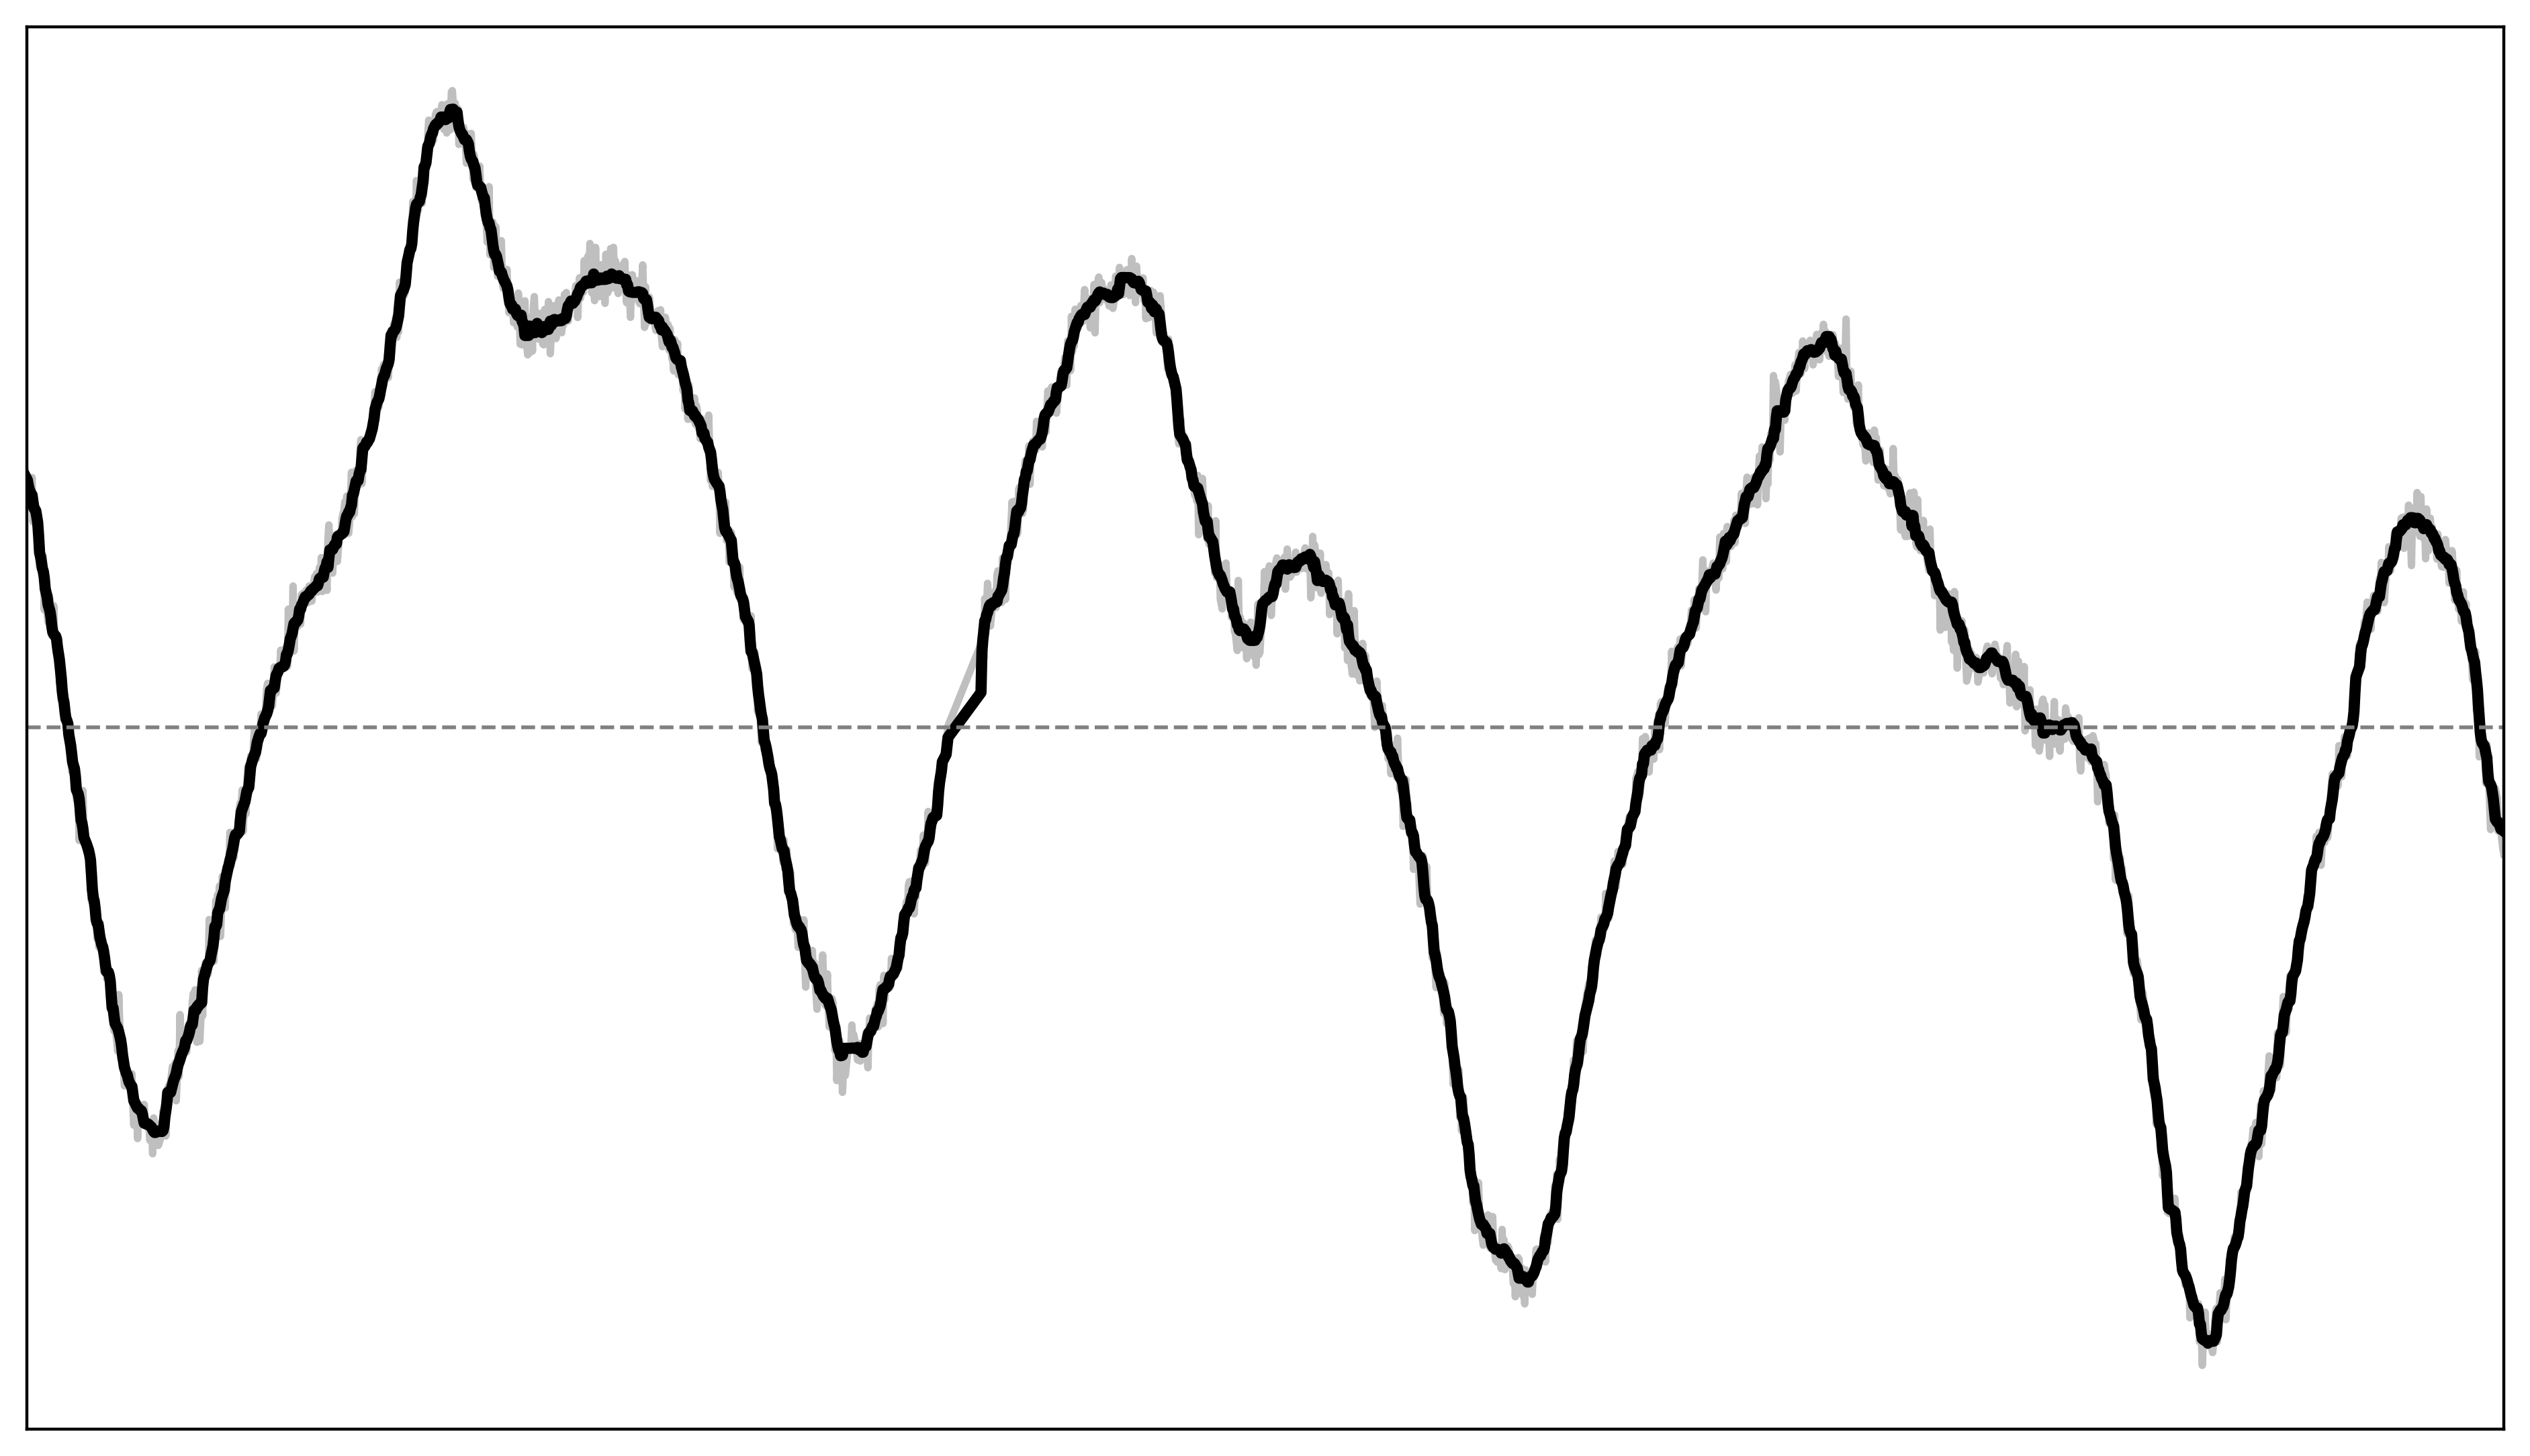

4141 valid points over 93.7 days
robust peak-to-peak (0.5--99.5 percentile) = 1.003%


In [ ]:
KEPLER_LC_PATH = Path("data/kic11599385_kepler_q05.csv")
KIC_ID = 11599385
KEPLER_QUARTER = 5
ROTATION_PERIOD_DAYS = 23.94

kepler_lc = pd.read_csv(KEPLER_LC_PATH)
valid_lc = (
    np.isfinite(kepler_lc["time_bkjd"])
    & np.isfinite(kepler_lc["pdcsap_flux_e_per_s"])
    & np.isfinite(kepler_lc["pdcsap_flux_err_e_per_s"])
    & (kepler_lc["sap_quality"] == 0)
)
kepler_lc = kepler_lc.loc[valid_lc].sort_values("time_bkjd").reset_index(drop=True)

flux_median = kepler_lc["pdcsap_flux_e_per_s"].median()
relative_flux = kepler_lc["pdcsap_flux_e_per_s"] / flux_median - 1.0
relative_median = relative_flux.median()
relative_mad_sigma = 1.4826 * np.median(np.abs(relative_flux - relative_median))
if not np.isfinite(relative_mad_sigma) or relative_mad_sigma <= 0.0:
    raise ValueError(f"Invalid flux scatter in {KEPLER_LC_PATH}")
kepler_lc = kepler_lc.loc[
    np.abs(relative_flux - relative_median) < 5.0 * relative_mad_sigma
].copy()
if len(kepler_lc) < 2:
    raise ValueError(f"Not enough valid Kepler data in {KEPLER_LC_PATH}")

kepler_lc["time_days"] = kepler_lc["time_bkjd"] - kepler_lc["time_bkjd"].min()
kepler_lc["brightness_percent"] = 100.0 * (
    kepler_lc["pdcsap_flux_e_per_s"] / flux_median - 1.0
)
kepler_lc["brightness_6h_percent"] = (
    kepler_lc["brightness_percent"].rolling(12, center=True, min_periods=1).median()
)
robust_peak_to_peak = np.diff(
    np.percentile(kepler_lc["brightness_percent"], [0.5, 99.5])
)[0]
time_span = kepler_lc["time_days"].max()

fig_star, ax_star = plt.subplots(figsize=(10, 6))
ax_star.plot(
    kepler_lc["time_days"], kepler_lc["brightness_percent"],
    color="0.75", lw=2, label="Kepler long cadence",
)
ax_star.plot(
    kepler_lc["time_days"], kepler_lc["brightness_6h_percent"],
    color="k", lw=3.0, label="6-hour rolling median",
)
# ax_star.axvspan(
#     0.0, ROTATION_PERIOD_DAYS, color="tab:blue", alpha=0.08,
#     label=rf"one published rotation: {ROTATION_PERIOD_DAYS:.2f} d",
# )
ax_star.axhline(0.0, color="0.5", lw=1.0, ls="--")
ax_star.set(
    # xlabel="Time since start of Kepler Quarter 5 [day]",
    # ylabel="Relative brightness [\%]",
    # title=f"KIC {KIC_ID}: Kepler Quarter {KEPLER_QUARTER} PDCSAP light curve",
    xlim=(40, time_span),
)
ax_star.set_xticks([])
ax_star.set_yticks([])
# ax_star.grid(alpha=0.2)
# ax_star.legend(loc="best")
fig_star.tight_layout()
plt.show()

print(f"{len(kepler_lc)} valid points over {time_span:.1f} days")
print(f"robust peak-to-peak (0.5--99.5 percentile) = {robust_peak_to_peak:.3f}%")
